# M4A2 - GANs

Na prática de hoje vamos treinar um modelo do tipo GAN utilizando [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Treinar Modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

In [ ]:
batch_size = 100
# Testar com menor 
# batch_size = 50
# batch_size = 200

# MNIST Dataset.
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5), std=(0.5))])

train_dataset = torchvision.datasets.MNIST(root='./mnist_data/', train=True, transform=transform, download=True)
# train_dataset = torchvision.datasets.KMNIST(root='./kmnist_data/', train=True, transform=transform, download=True)
# train_dataset = torchvision.datasets.FashionMNIST(root='./fashion_mnist_data', train=True, transform=transform, download=True)
# Data Loader.
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

## Treinar Modelo

Agora vamos criar os modelos e treinar ele.

In [84]:
########################
## Criando os modelos ##
########################


# Gerador.
class Generator(torch.nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super(Generator, self).__init__()       
        self.fc1 = torch.nn.Linear(g_input_dim, 256)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features*2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features*2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, g_output_dim)
    
    # método forward. 
    def forward(self, x): 
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        return torch.tanh(self.fc4(x))

# Discrimador.
class Discriminator(torch.nn.Module):
    def __init__(self, d_input_dim):
        super(Discriminator, self).__init__()
        self.fc1 = torch.nn.Linear(d_input_dim, 1024)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features//2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features//2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, 1)
    
    # método forward. 
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        return torch.sigmoid(self.fc4(x))

In [ ]:
# Instanciar as redes.
z_dim = 100
# Com z_dim menor as imagens que aparecem são só ruidos, ambos os modelos não aprendem
# z_dim = 20 
# Com z_dim maior, as imagens começam com ruidos e o Generator vai aprendendo
# z_dim = 200
mnist_dim = train_dataset.train_data.size(1) * train_dataset.train_data.size(2)

device = "mps" if torch.mps.is_available() else "cpu"
G = Generator(g_input_dim = z_dim, g_output_dim = mnist_dim).to(device)
D = Discriminator(mnist_dim).to(device)

In [101]:
# Função de perda.
criterion = torch.nn.BCELoss() 

# Otimizador. Learning Rate ( o Gerador ganhava gradativamente )
lr = 0.0002
# Com Gerador sendo menor que o Discriminador (Começava equilibrado)
# lr_g = 0.0001
# lr_d = 0.0002
# Com o Gerador sendo maior que o Discriminador
# lr_g = 0.0003
# lr_d = 0.0002
# Com valores muito diferentes 
# lr_g = 0.001
# lr_d = 0.0002

G_optimizer = torch.optim.Adam(G.parameters(), lr = lr)
D_optimizer = torch.optim.Adam(D.parameters(), lr = lr)


In [102]:
def D_train(x):
    #=======================Treino do discriminador=======================#
    D.zero_grad()

    # Treina discriminador em dados reais.
    x_real, y_real = x.view(-1, mnist_dim), torch.ones(batch_size, 1)
    x_real, y_real = torch.autograd.Variable(x_real.to(device)), torch.autograd.Variable(y_real.to(device))

    D_output = D(x_real)
    D_real_loss = criterion(D_output, y_real)
    D_real_score = D_output

    # Treina discriminador em dados falsos.
    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    x_fake, y_fake = G(z), torch.autograd.Variable(torch.zeros(batch_size, 1).to(device))

    D_output = D(x_fake)
    D_fake_loss = criterion(D_output, y_fake)
    D_fake_score = D_output

    # Backpropagation e otimização dos parâmetros do discriminador.
    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_optimizer.step()
        
    return  D_loss.data.item()

def G_train(x):
    #=======================Treino do gerador=======================#
    G.zero_grad()

    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    y = torch.autograd.Variable(torch.ones(batch_size, 1).to(device))

    G_output = G(z)
    D_output = D(G_output)
    G_loss = criterion(D_output, y)

    # Backpropagation e otimização dos parâmetros do gerador.
    G_loss.backward()
    G_optimizer.step()
        
    return G_loss.data.item()

In [103]:
def show_generated(G, z_dim, n=20, title="Imagens geradas"):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, z_dim, device=device)
        imgs = G(z).view(n, 1, 28, 28).cpu()
    grid = torchvision.utils.make_grid(
        imgs,
        nrow=10,
        normalize=True
    )

    plt.figure(figsize=(14, 3))
    plt.imshow(
        grid.permute(1, 2, 0).numpy(),
        cmap='gray'
    )
    plt.title(title)
    plt.axis('off')

[1/50]: loss_d: 0.936, loss_g: 2.415
[2/50]: loss_d: 0.779, loss_g: 3.598
[3/50]: loss_d: 1.006, loss_g: 1.566
[4/50]: loss_d: 1.050, loss_g: 1.630
[5/50]: loss_d: 0.973, loss_g: 1.970
[6/50]: loss_d: 1.008, loss_g: 2.132
[7/50]: loss_d: 0.816, loss_g: 1.998
[8/50]: loss_d: 0.844, loss_g: 1.924
[9/50]: loss_d: 0.656, loss_g: 2.106
[10/50]: loss_d: 0.722, loss_g: 1.900
[11/50]: loss_d: 0.622, loss_g: 1.995
[12/50]: loss_d: 0.726, loss_g: 1.774
[13/50]: loss_d: 0.595, loss_g: 2.506
[14/50]: loss_d: 0.648, loss_g: 1.988
[15/50]: loss_d: 0.600, loss_g: 2.302
[16/50]: loss_d: 0.618, loss_g: 2.414
[17/50]: loss_d: 0.688, loss_g: 2.093
[18/50]: loss_d: 0.712, loss_g: 2.426
[19/50]: loss_d: 0.647, loss_g: 2.540
[20/50]: loss_d: 0.600, loss_g: 2.363
[21/50]: loss_d: 0.665, loss_g: 2.270
[22/50]: loss_d: 0.689, loss_g: 2.051
[23/50]: loss_d: 0.734, loss_g: 2.123
[24/50]: loss_d: 0.605, loss_g: 2.331
[25/50]: loss_d: 0.776, loss_g: 1.911
[26/50]: loss_d: 0.693, loss_g: 2.028
[27/50]: loss_d: 0.74

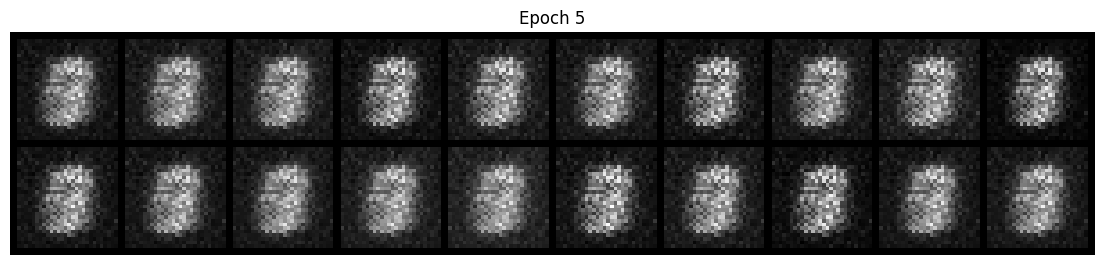

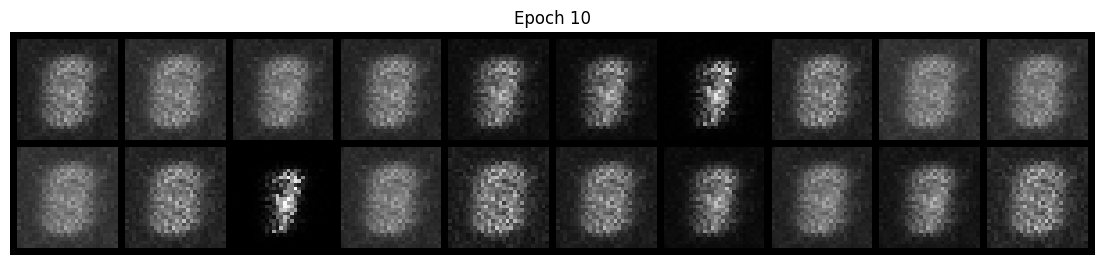

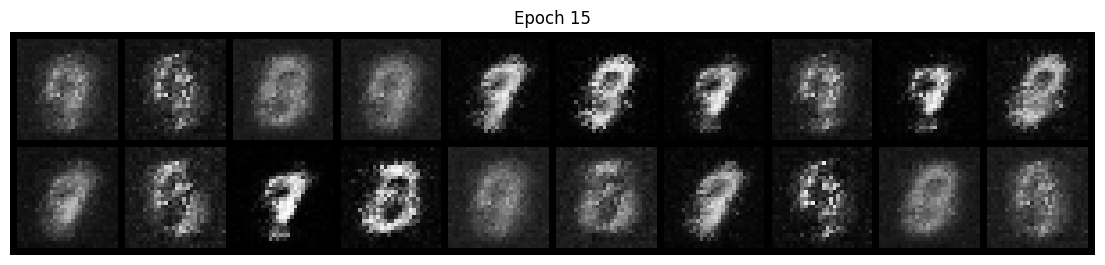

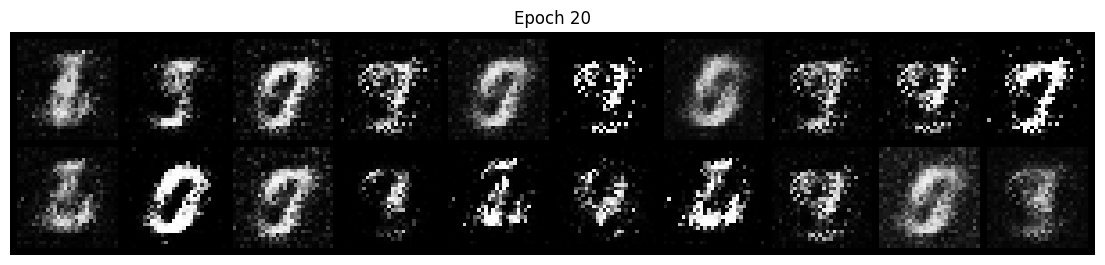

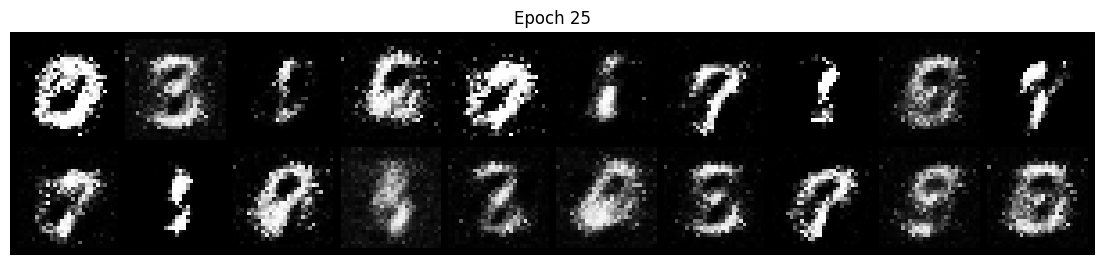

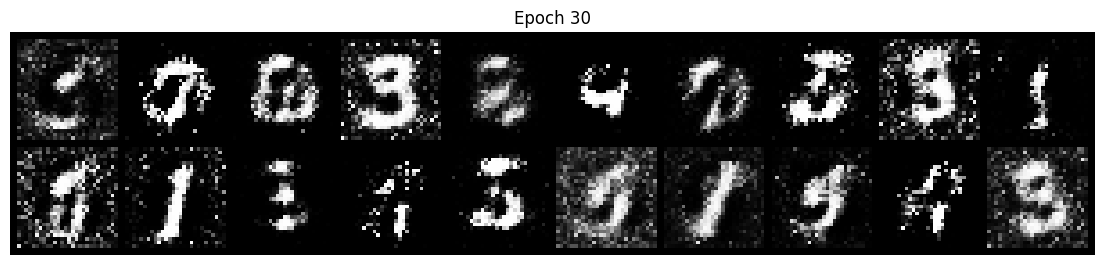

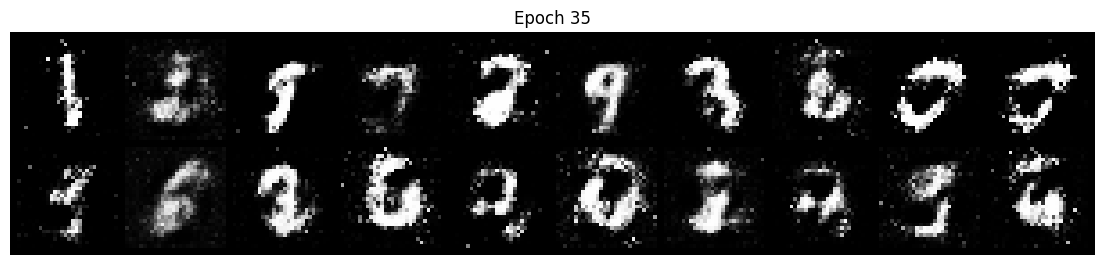

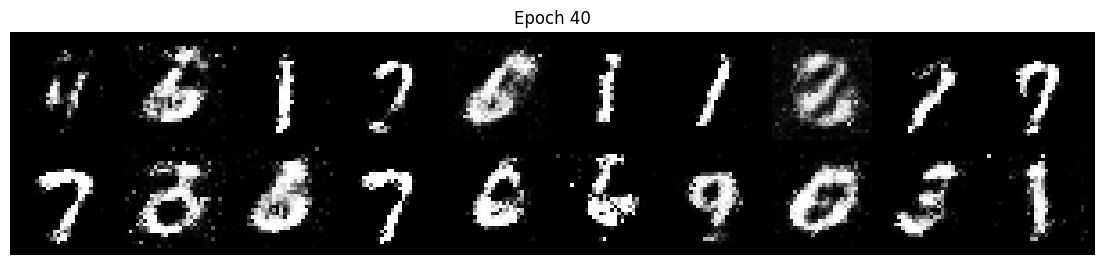

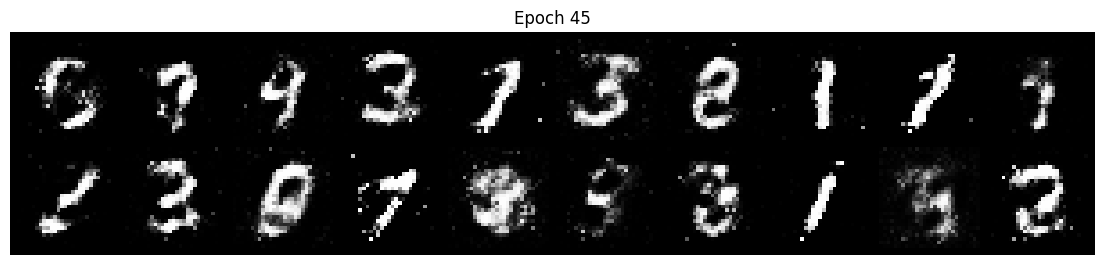

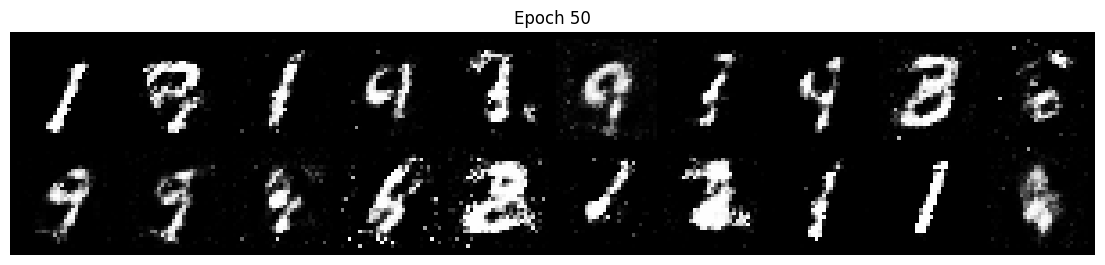

In [104]:
# Laço de treino.
# n_epoch = 200
n_epoch = 50
for epoch in range(1, n_epoch+1):           
    D_losses, G_losses = [], []
    for batch_idx, (x, _) in enumerate(train_loader):
        D_losses.append(D_train(x))
        G_losses.append(G_train(x))
    if (epoch + 1) % 5 == 0:
        show_generated(
            G,
            z_dim,
            title= f"Epoch {epoch + 1}"
        )

    print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' % (
            (epoch), n_epoch, torch.mean(torch.FloatTensor(D_losses)), torch.mean(torch.FloatTensor(G_losses))))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


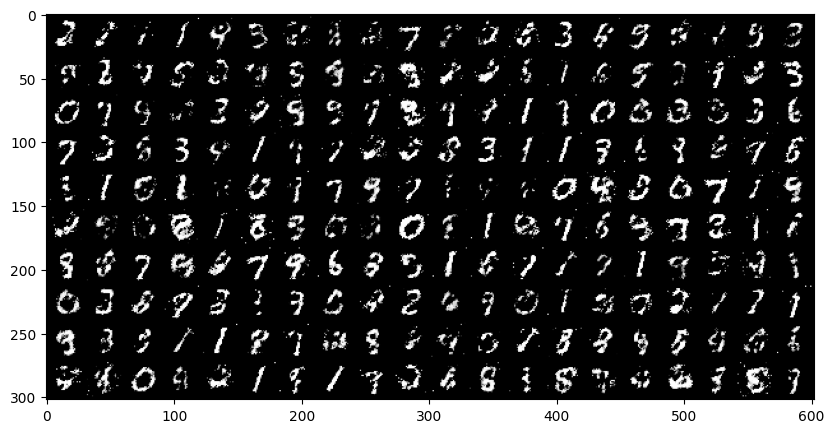

In [105]:
# Inferência com modelo treinado.
with torch.no_grad():
    test_z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    generated = G(test_z)

generated = generated.view(generated.size(0), 1, 28, 28)
grid = torchvision.utils.make_grid(generated.cpu(), 20)
grid = grid.permute(1, 2, 0).numpy()
plt.figure(figsize=(20, 5))
plt.imshow(grid.squeeze(), cmap='gray')


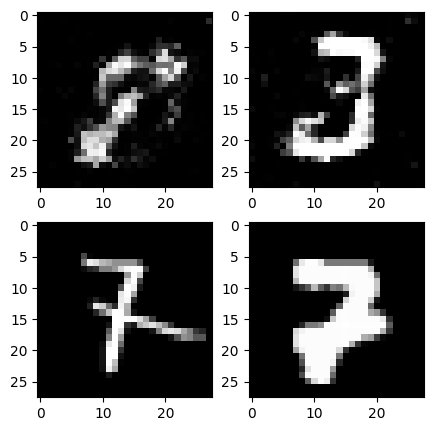

In [107]:
# Comparação resultados dos modelos e dados da base.
indexes_gen = [np.random.randint(0, batch_size), np.random.randint(0, batch_size)]
indexes_data = [np.random.randint(0, len(train_dataset)), np.random.randint(0, len(train_dataset))]

index = 0

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
axes[0, 0].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[0]].transpose(1, 2, 0), cmap="gray")
axes[0, 1].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[1]].transpose(1, 2, 0), cmap="gray")
axes[1, 0].imshow(train_dataset[indexes_data[0]][0].numpy().transpose(1,2,0), cmap="gray")
axes[1, 1].imshow(train_dataset[indexes_data[1]][0].numpy().transpose(1,2,0), cmap="gray")

## Próximos Passos e Referências

Nas próximas práticas vamos trabalhar com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/lyeoni/pytorch-mnist-GAN
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente alterar a base de dados e veja se o modelo continua funcionando?
- [ ] Tente alterar alguns hiperparâmetros de treinamento, como learning rate, batch, e veja como isso altera os resultados.